*PART 1*

# **Data Preperation**

## Extract the Database

clear the directory
  

In [110]:
from google.colab import drive
drive.flush_and_unmount()

In [111]:
from google.colab import drive
drive.mount('/content/drive')

#the path
zip_path = '/content/drive/My Drive/Biometrics/CASIA-FaceV5(BMP).zip'

#unzip
!unzip '/content/drive/My Drive/Biometrics/CASIA-FaceV5(BMP).zip' -d '/content/dataset/'

Mounted at /content/drive
Archive:  /content/drive/My Drive/Biometrics/CASIA-FaceV5(BMP).zip
replace /content/dataset/Face/000/000_0.bmp? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


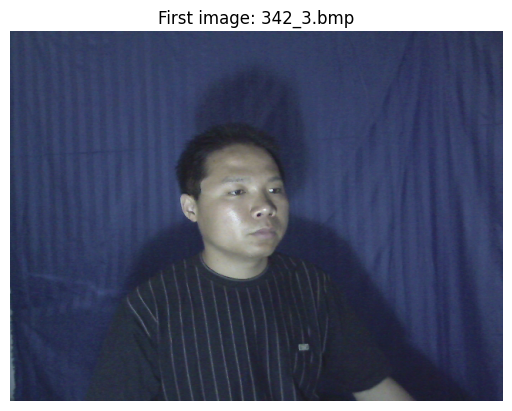

In [112]:
import os
import cv2
import matplotlib.pyplot as plt
dataset_path = '/content/dataset/'

image_files = [os.path.join(root, file)
               for root, _, files in os.walk(dataset_path)
               for file in files if file.endswith('.bmp')]

##for example###
# Load the first image
image_path = image_files[0]
image = cv2.imread(image_path)
# Convert BGR to RGB for displaying in matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Display the image
plt.imshow(image_rgb)
plt.title(f"First image: {os.path.basename(image_path)}")
plt.axis('off')  # Hide axis
plt.show()


## Make Genuine vs. Imposter tests

In [113]:
import random
from itertools import combinations

grouping all the images of a spicific person together in a dictionary "persons_images" where </br> key -> person id (0-499) </br> value -> list of 5 image file paths.

In [114]:
dataset_path = '/content/dataset/Face'

persons_images = {}

for root, dirs, files in os.walk(dataset_path):
  for file in files:
    if file.endswith('.bmp'):
      id = os.path.basename(root)
      #when the list is still empty
      if id not in persons_images:
        persons_images[id] = []
      persons_images[id].append(os.path.join(root, file))

since the database has 500 people and each person has 5 impressions (photo samples), then we can produce 12,500 genuin test (5* 5* 500). but thats a lot of tests. So we'll select randomlly a spicific number of genuine tests.

In [115]:
def make_genuine_tests(persons_images, limit = None):
  genuine_tests = []

  #to randomize the order if people
  peoples_ids = list(persons_images.keys())
  random.shuffle(peoples_ids)

  for id in peoples_ids:
    image_list = persons_images[id]
    if len(image_files) > 1:
      pairs = list(combinations(image_list, 2))
      if limit is not None:
        random.shuffle(pairs)
        pairs = pairs[:limit]
      genuine_tests.extend(pairs)
    if limit is not None:
      random.shuffle(genuine_tests)
      genuine_tests = genuine_tests[:limit]
  return genuine_tests

in order not to create any biases, well make the same number of imposter tests.

In [116]:
def make_imposter_tests(persons_images, limit = None):
  #using a set in order to avoid duplication tests!
  imposter_tests = set()

  #to randomize the order of people
  peoples_ids = list(persons_images.keys())
  pair_combination = list(combinations(peoples_ids, 2))
  random.shuffle(pair_combination)

  for id1, id2 in pair_combination:

    if len(imposter_tests) >= limit: break

    img1 = random.choice(persons_images[id1])
    img2 = random.choice(persons_images[id2])
    imposter_tests.add((img1, img2))

  #at last, return as a list
  return list(imposter_tests)

**Create the tests!!**

In [141]:
lim = 500
genuine_tests = make_genuine_tests(persons_images, lim)
imposter_tests = make_imposter_tests(persons_images, lim)
print("Number of Genuine Pairs:", len(genuine_tests))
print("Number of Imposter Pairs:", len(imposter_tests))


Number of Genuine Pairs: 500
Number of Imposter Pairs: 500


download the genuine and imposter test sets

In [178]:
import pandas as pd

genuine_df = pd.DataFrame(genuine_tests, columns=['img1', 'img2'])
imposter_df = pd.DataFrame(imposter_tests, columns=['img1', 'img2'])

#save as CSV
genuine_df.to_csv('genuine_tests.csv', index=False)
imposter_df.to_csv('imposter_tests.csv', index=False)

#**Set up the tools**

 install the tools

## ARCFACE

In [119]:
!pip install insightface
!pip install onnxruntime

import the libraries, and make function for feature extraction

In [120]:
import insightface
import argparse

#provides functionalities like face detection and feature extraction
from insightface.app import FaceAnalysis
# general
assert insightface.__version__>='0.3'
parser = argparse.ArgumentParser(description='insightface app test')

parser.add_argument('--ctx', default=0, type=int, help='ctx id, <0 means using cpu')
parser.add_argument('--det-size', default=640, type=int, help='detection size')
args, unknown = parser.parse_known_args()

app = FaceAnalysis()
#CPU will be used for computation
app.prepare(ctx_id=args.ctx, det_size=(args.det_size,args.det_size))

def arcface_feature_extraction (image):

  #detect faces
  face = app.get(image)
  if len(face) > 0:
    #return first face's features
    return face[0].embedding
  print("No face detected")
  #no faces detected
  return None

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


## VGG

use the model from 'tensorflow'

In [121]:
import numpy as np
import cv2
import tensorflow as tf
# from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions


Based on RESNET50 architecture -> new paper(2017)


In [122]:
vgg_model = ResNet50(weights='imagenet')

def vgg_feature_extraction (img):
  img = cv2.resize(img,(224,224))
  #expand dim to match model input
  img = np.expand_dims(img, axis = 0)
  img = preprocess_input(img)
  prediction = vgg_model.predict(img)

  print('Predicted:', decode_predictions(prediction))

  return prediction

## DeepFace

installation

In [123]:
!pip install deepface
!pip install tensorflow


as apposed to previouse functions, this one already calculated the distance between two image feature vectors

In [124]:
from deepface import DeepFace


def deepface_feature_extraction(image):
  #chose model with the highest measured and declared scores
  embedding_obj = DeepFace.represent(image, model_name="Facenet512", enforce_detection=False)
  if embedding_obj is not None:
    return embedding_obj[0]["embedding"]
  return None

# print(deepface_feature_extraction(genuine_tests[0][0]))

# **Calc Distances**

Cosine similarity calculation

In [142]:
def distance(feature_v1, feature_v2):
    vector1 = np.array(feature_v1).flatten()
    vector2 = np.array(feature_v2).flatten()

    # Calculate the dot product
    dot_product = np.dot(vector1, vector2)

    # Calculate the norms (magnitudes) of the vectors
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)

    # Avoid division by zero
    if norm_vector1 == 0 or norm_vector2 == 0:
        return 0.0

    # Calculate cosine similarity
    cosine_sim = dot_product / (norm_vector1 * norm_vector2)

    return cosine_sim

all extraction functions get the image in RBG format.

In [143]:
def load_convertRGB_image(path):
  img = cv2.imread(path)
  if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  else:
    #handle error in caller
    print(f"Image not found or corrupted: {path}")
    return None
  return img

general method for all tools</br> for computing the distances between two images.


In [144]:
from tqdm import tqdm
def compute_image_dist(test_pairs, feature_extractor, tool):
  distances = []
  image_pairs = []
  for (img1, img2) in tqdm(test_pairs,desc=tool):
  # for (img1, img2) in test_pairs:
    img1_rgb = load_convertRGB_image(img1)
    img2_rgb = load_convertRGB_image(img2)

    #if img1 is not None and img2 is not None:
    vec1 = feature_extractor(img1_rgb)
    vec2 = feature_extractor(img2_rgb)
    if vec1 is not None and vec2 is not None:
      dist = distance(vec1, vec2)
    if dist is not None:
        distances.append(dist)
        image_pairs.append((dist, img1, img2))
    else:
      print("image load fail")
  # return distances, image_pairs
  return distances, image_pairs

extract dist for **arcface**

In [145]:
print("genuine")
genuine_distance_arcface, genuine_pairs_arcface = compute_image_dist(genuine_tests, arcface_feature_extraction,"ArcFace - Testing genuine")
print("imposter")
imposter_distance_arcface, imposter_pairs_arcface = compute_image_dist(imposter_tests, arcface_feature_extraction,"ArcFace - Testing imposter")


genuine


ArcFace - Testing genuine: 100%|██████████| 500/500 [20:33<00:00,  2.47s/it]


imposter


ArcFace - Testing imposter: 100%|██████████| 500/500 [20:41<00:00,  2.48s/it]


extract dist for **vggface**

In [146]:
print("genuine")
genuine_distance_vgg, genuine_pairs_vgg = compute_image_dist(genuine_tests, vgg_feature_extraction,"VGGFace - Testing genuine")
print("imposter")
imposter_distance_vgg, imposter_pairs_vgg = compute_image_dist(imposter_tests, vgg_feature_extraction,"VGGFace - Testing imposter")


genuine


VGGFace - Testing genuine:   0%|          | 0/500 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
Predicted: [[('n03721384', 'marimba', 0.22679992), ('n04418357', 'theater_curtain', 0.08692135), ('n04296562', 'stage', 0.08411123), ('n03141823', 'crutch', 0.057487626), ('n03250847', 'drumstick', 0.04249849)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


VGGFace - Testing genuine:   0%|          | 1/500 [00:00<07:15,  1.15it/s]

Predicted: [[('n03250847', 'drumstick', 0.12504905), ('n03721384', 'marimba', 0.11225853), ('n04296562', 'stage', 0.10255264), ('n04418357', 'theater_curtain', 0.096348844), ('n03788365', 'mosquito_net', 0.06616805)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Predicted: [[('n04418357', 'theater_curtain', 0.6982895), ('n04209239', 'shower_curtain', 0.12323838), ('n03788365', 'mosquito_net', 0.079658344), ('n04296562', 'stage', 0.023790084), ('n04039381', 'racket', 0.0097456435)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


...

Predicted: [[('n04418357', 'theater_curtain', 0.22582565), ('n03595614', 'jersey', 0.1770892), ('n04039381', 'racket', 0.10614044), ('n03452741', 'grand_piano', 0.057575956), ('n04296562', 'stage', 0.04911342)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Predicted: [[('n03788365', 'mosquito_net', 0.3035319), ('n04418357', 'theater_curtain', 0.19112924), ('n04296562', 'stage', 0.063881345), ('n03452741', 'grand_piano', 0.05160556), ('n04039381', 'racket', 0.03656645)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


VGGFace - Testing imposter: 100%|█████████▉| 499/500 [07:27<00:00,  1.24it/s]

Predicted: [[('n04296562', 'stage', 0.26495597), ('n04039381', 'racket', 0.17586109), ('n04418357', 'theater_curtain', 0.117377214), ('n03617480', 'kimono', 0.035980593), ('n03721384', 'marimba', 0.034955166)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
Predicted: [[('n04296562', 'stage', 0.25926518), ('n03452741', 'grand_piano', 0.13656649), ('n04418357', 'theater_curtain', 0.10588798), ('n02804610', 'bassoon', 0.10422467), ('n02992211', 'cello', 0.09251441)]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


VGGFace - Testing imposter: 100%|██████████| 500/500 [07:27<00:00,  1.12it/s]

Predicted: [[('n04039381', 'racket', 0.23984364), ('n03888605', 'parallel_bars', 0.095589176), ('n03721384', 'marimba', 0.083950184), ('n04296562', 'stage', 0.082440674), ('n03250847', 'drumstick', 0.075824365)]]


extract dist for **deepface**

In [147]:
print("genuine")
genuine_distance_deep,genuine_pairs_deep = compute_image_dist(genuine_tests,deepface_feature_extraction,"DeepFace - Testing genuine")
print("imposter")
imposter_distance_deep, imposter_pairs_deep = compute_image_dist(imposter_tests,deepface_feature_extraction,"DeepFace - Testing imposter")


genuine


DeepFace - Testing genuine: 100%|██████████| 500/500 [18:17<00:00,  2.19s/it]


imposter


DeepFace - Testing imposter: 100%|██████████| 500/500 [18:49<00:00,  2.26s/it]


# **ROC**

In [158]:
from sklearn.preprocessing import MinMaxScaler

def normalize_scores(scores):
  scaler = MinMaxScaler()
  return scaler.fit_transform(np.array(scores).reshape(-1, 1)).flatten()

prints a ROC for a tool

In [159]:
from sklearn.metrics import roc_curve, auc

def plot_ROC(genuine_dist, imposter_dist, name):

  genuine_dist = normalize_scores(genuine_dist)
  imposter_dist = normalize_scores(imposter_dist)
  #label class genuine - 1 (true)
  #label imposter - 0
  true_label = [1] * len(genuine_dist) + [0] * len(imposter_dist)
  predicted_label = list(genuine_dist) +  list(imposter_dist)

  false_positive_rate, true_positive_rate, _ = roc_curve(true_label,predicted_label)
  #calculate the Area Under the Curve
  roc_auc_score = auc(false_positive_rate, true_positive_rate)

  plt.plot(false_positive_rate, true_positive_rate, lw=2, label =f'{name} (AUC = {roc_auc_score:.2f})')
  return false_positive_rate, true_positive_rate, roc_auc_score

plot ROC for all tools

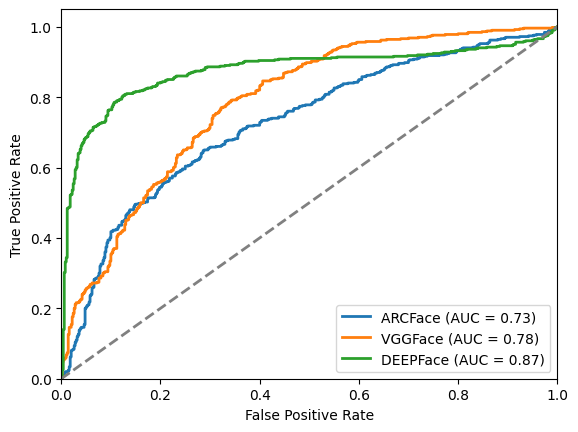

In [160]:
fpr_arcface, tpr_arcface, auc_arcface = plot_ROC(genuine_distance_arcface, imposter_distance_arcface, 'ARCFace')
fpr_vggface, tpr_vggface, auc_vggface = plot_ROC(genuine_distance_vgg, imposter_distance_vgg, 'VGGFace')
fpr_deepface, tpr_deepface, auc_deepface = plot_ROC(genuine_distance_deep, imposter_distance_deep, 'DEEPFace')

#add a 50/50 guess line
plt.plot([0,1], [0,1], color='gray', lw=2, linestyle='--')
#X and Y axis limit:
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# **Display FMR/FNMR on some threshold**

General function that calculates FMR and FNMR</br>
is used by all tools

In [179]:
def calc_FMR_FNMR(fpr, tpr, thresholds):

  #table like print:)
  print("\nThreshold\tFMR\tFNMR")
  print("-" * 30)

  for threshold in thresholds:
    #find the index of the closest value in the thresholds array that matches or exceeds a given threshold value
    idx = np.searchsorted(thresholds, threshold, side='left')
    if idx >= len(fpr):
      idx = len(fpr) - 1
    elif idx > 0 and (idx == len(fpr) or thresholds[idx] > threshold):
            idx -= 1
    fmr = fpr[idx]
    fnmr = 1 - tpr[idx]
    print(f"{threshold:.1f}\t\t{fmr:.3f}\t{fnmr:.3f}")

print the results on the following thresholds

In [180]:
thresholds = [0.1, 0.2,0.3,0.4,0.5, 0.6,0.7, 0.8,0.9]

#arcface
print("Arcface")
calc_FMR_FNMR(fpr_arcface,tpr_arcface,thresholds)
#vggface
print("VGGface")
calc_FMR_FNMR(fpr_vggface,tpr_vggface,thresholds)
#deepface
print("Deepface")
calc_FMR_FNMR(fpr_deepface, tpr_deepface, thresholds)

Arcface

Threshold	FMR	FNMR
------------------------------
0.1		0.000	1.000
0.2		0.002	0.998
0.3		0.002	0.990
0.4		0.008	0.990
0.5		0.008	0.980
0.6		0.014	0.980
0.7		0.014	0.976
0.8		0.016	0.976
0.9		0.016	0.966
VGGface

Threshold	FMR	FNMR
------------------------------
0.1		0.000	1.000
0.2		0.002	0.998
0.3		0.002	0.952
0.4		0.004	0.952
0.5		0.004	0.946
0.6		0.006	0.946
0.7		0.006	0.944
0.8		0.008	0.944
0.9		0.008	0.940
Deepface

Threshold	FMR	FNMR
------------------------------
0.1		0.000	1.000
0.2		0.002	1.000
0.3		0.002	0.974
0.4		0.004	0.974
0.5		0.004	0.860
0.6		0.006	0.860
0.7		0.006	0.698
0.8		0.008	0.698
0.9		0.008	0.668


#  *PART 2*

the method: **Gradient Boosting** - a ML model

step 1: normalize  scores

step 2 : preparing the tests

In [163]:
def preprocess(genuine, imposter):

  #this step is done for getting the train and test pairs later as a CSV

  genuine_dist = [gen[0] for gen in genuine]
  genuine_pairs = [(gen[1], gen[2])for gen in genuine]

  imposter_dist = [imp[0] for imp in imposter]
  imposter_pairs = [(imp[1], imp[2])for imp in imposter]

  #normalize all the distances
  genuine_dist = normalize_scores(genuine_dist)
  imposter_dist = normalize_scores(imposter_dist)

  #combined matrix
  X = np.concatenate([genuine_dist ,imposter_dist] )
  #the ture labels:
  y = np.array([1]*len(genuine_dist) + [0]* len(imposter_dist))

  return X, y, genuine_pairs, imposter_pairs

step 3: training the model

In [173]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

def gradient_boosting_roc(genuine, imposter):
  X, y, genuine_pairs, imposter_pairs = preprocess(genuine, imposter)

  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size= 0.5, random_state=42)

  #before performing the method..collect the corresponding train ans test pairs:
  train_pairs = [(genuine_pairs[i][0], genuine_pairs[i][1])
                    for i in range(len(genuine_pairs)) if i < len(X_train) and y_train[i]==1] + \
                [(imposter_pairs[i][0], imposter_pairs[i][1])
                    for i in range(len(imposter_pairs)) if i < len(X_train) and y_train[i]==0]

  validation_pairs = [(genuine_pairs[i][0], genuine_pairs[i][1])
                    for i in range(len(genuine_pairs)) if i < len(X_val) and y_val[i]==1] + \
                [(imposter_pairs[i][0], imposter_pairs[i][1])
                    for i in range(len(imposter_pairs)) if i < len(X_val) and y_val[i]==0]


  model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
  model.fit(X_train.reshape(-1, 1), y_train)

  scores = model.predict_proba(X_val.reshape(-1, 1))[:, 1]

  fpr, tpr, _ = roc_curve(y_val, scores)
  roc_auc = auc(fpr, tpr)

  plt.plot(fpr, tpr, lw=2, label =f"Gradient Boosting (AUC = {roc_auc:.2f})")

  return fpr, tpr, roc_auc, train_pairs, validation_pairs

USAGE

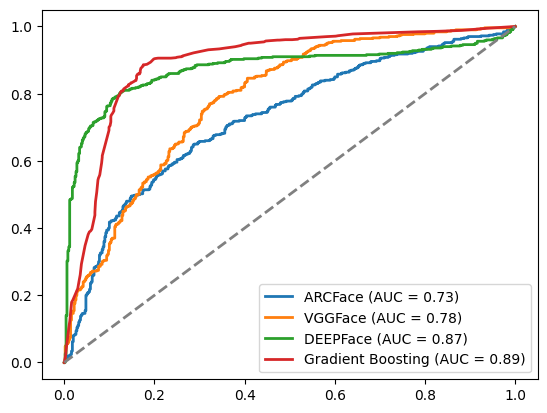

In [175]:
#the genuine and imposter distances from the three tools
genuine = [pair for model_pairs in [genuine_pairs_arcface,genuine_pairs_vgg, genuine_pairs_deep] for pair in model_pairs]
imposter = [pair for model_pairs in [imposter_pairs_arcface, imposter_pairs_vgg, imposter_pairs_deep] for pair in model_pairs]


#print for comparison:
fpr_arcface, tpr_arcface, auc_arcface = plot_ROC(genuine_distance_arcface, imposter_distance_arcface, 'ARCFace')
fpr_vggface, tpr_vggface, auc_vggface = plot_ROC(genuine_distance_vgg, imposter_distance_vgg, 'VGGFace')
fpr_deepface, tpr_deepface, auc_deepface = plot_ROC(genuine_distance_deep, imposter_distance_deep, 'DEEPFace')
fpr_combined, tpr_combined, auc_combined, train_pairs, validation_pairs = gradient_boosting_roc(genuine, imposter)

#add a 50/50 guess line
plt.plot([0,1], [0,1], color='gray', lw=2, linestyle='--')

plt.legend(loc="lower right")
plt.show()

In [176]:
print("comnined")
calc_FMR_FNMR(fpr_combined, tpr_combined, thresholds)

comnined

Threshold	FMR	FNMR
------------------------------
0.1		0.000	1.000
0.2		0.003	0.982
0.3		0.005	0.948
0.4		0.010	0.903
0.5		0.010	0.902
0.6		0.012	0.877
0.7		0.016	0.821
0.8		0.019	0.814
0.9		0.030	0.780


saving the training and validation pairs in CSV

In [177]:
pd.DataFrame(train_pairs, columns=['img1', 'img2']).to_csv('train_pairs.csv', index=False)
pd.DataFrame(validation_pairs, columns=['img1', 'img2']).to_csv('validation_pairs.csv', index=False)